## **Drugi domaći zadatak**

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, laplace, poisson, binom, cauchy, gamma, beta, chi2, expon
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture as GM
import io, requests, pandas as pd

In [3]:
#Prikupljamo skup podataka o egzoplanetama iz NASA Exoplanet Archive

TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

#Uzimaju se parametri: orbitalni period [dan], radijus planete [R_z], rav. temp, metalicnost zv.
query = '''
SELECT 
    pl_orbper,
    pl_rade,
    pl_eqt,
    st_met,
    discoverymethod
FROM pscomppars
'''

r = requests.get(TAP_URL, params={"query": query, "format": "csv"},
                 timeout=120)
exo = pd.read_csv(io.StringIO(r.text))
exo.head()

,pl_orbper,pl_rade,pl_eqt,st_met,discoverymethod
0,1.003934,1.710000,1419.0,-0.05,Transit
1,8.172400,3.323214,858.0,-0.06,Transit
2,6.283855,0.800000,1108.0,0.07,Transit
3,3.173917,3.150000,1655.0,0.08,Transit
4,56.358501,4.540605,419.0,-0.20,Transit


#### **Prvi zadatak**
Naći udeo vrućih Jupitera u prikupljenom skupu podataka i prikazati rezultat u procentima

In [5]:
#Definisemo klasu vrucih Jupitera
exo["Vj"] = ((exo["pl_orbper"] < 10) & (exo["pl_rade"] > 8)).astype(int)

#Koliki je udeo vrucih Jupitera u celom skupu podataka
udeo = exo["Vj"].sum() / len(exo)

print("Udeo vrućih Jupitera = {:.2f}%".format(udeo * 100))

Udeo vrućih Jupitera = 11.77%


#### **Drugi zadatak**

Zvezdana metaličnost $[Fe/H]$ je važan faktor u predviđanju formiranja džinovskih planeta. Pokazati da zvezde sa $[Fe/H] > 0.4$ imaju značajno veći udeo vrućih Jupitera u odnosu na celi uzorak.

In [11]:
visoka_metal = exo[exo["st_met"] > 0.4]

#Pošto imamo promenljivu koja uzima vrednosti 0 i 1 srednja vrednost govori koliko je True vrednosti u odnosu na True + False (sum/len)
udeo_vm = visoka_metal["Vj"].mean() * 100

print("Broj planeta oko zvezda sa [Fe/H] > 0.4:", len(visoka_metal))
print("Broj vrućih Jupitera oko zvezda sa [Fe/H] > 0.4:", visoka_metal["Vj"].sum())
print("Udeo vrućih Jupitera oko zvezda sa [Fe/H] > 0.4: {:.2f}%".format(udeo_vm), ", što je 3 puta veće od udela vrućih Jupitera u odnosu na celi uzorak")

Broj planeta oko zvezda sa [Fe/H] > 0.4: 77
Broj vrućih Jupitera oko zvezda sa [Fe/H] > 0.4: 28
Udeo vrućih Jupitera oko zvezda sa [Fe/H] > 0.4: 36.36% , što je 3 puta veće od udela vrućih Jupitera u odnosu na celi uzorak


#### **Treći zadatak**

Koristeći se istim ovim uzorkom $([Fe/H] > 0.4)$, primeniti bootstrap metodu za procenu neodređenosti uzoračke srednje vrednosti $\bar{x}$ i uzoračke standardne devijacije $s$ za zvezdanu metaličnost. Uporediti dobijene raspodele sa analitičkim izrazima:

$$\sigma_{\bar{x}} = \frac{s}{\sqrt{N}}   \qquad  \sigma_{s} = \frac{s}{\sqrt{2(N - 1)}}$$

Prikazati pripadajuće grafike i diskutovati: da li je pretpostavka normalnosti jednako opravdana za $\bar{x}$ i za $s$? Da li bi rezultati $jackknife$ metode bili bolji od $bootstrap$ metode?

In [34]:
#uzorak zvezdane metaličnosti za [Fe/H] > 0.4
visoka_metal = exo[exo["st_met"] > 0.4].copy()
x = visoka_metal["st_met"].dropna().values

#broj uzoraka
N = len(x)

#srednja metalicnost uzorka
x_sr = np.mean(x)
#standardna devijacija metaličnosti u uzorku
x_std = np.std(x)

print("N =", N)
print("Srednja vrednost [Fe/H] =", np.round(x_sr, 2))
print("Standardna devijacija [Fe/H] =", np.round(x_std, 2))

N = 77
Srednja vrednost [Fe/H] = 0.45
Standardna devijacija [Fe/H] = 0.06


In [36]:
#I za jedan i za drugi se uviđa da, što je veći broj uzoraka, to je neodređenost manja
#Neodređenost srednje vrednosti po analitičkom modelu
sigma_sr_anal = x_std / np.sqrt(N)

#Neodređenost std po analitičkom
sigma_std_anal = x_std / np.sqrt(2 * (N - 1))

print("Analitička neodređenost srednje vrednosti =", np.round(sigma_sr_anal, 3))
print("Analitička neodređenost standardne devijacije =", np.round(sigma_std_anal, 3))

Analitička neodređenost srednje vrednosti = 0.007
Analitička neodređenost standardne devijacije = 0.005


In [39]:
#Sada radeći bootstrap metodu izvlačimo nove uzorke iste dužine ali će se elementi ponavljati
#Uradiće se na 1000 mogućih kombinacija
B = 10000

#Pravimo prazne nizove koji će se popuniti sa 1000 vr 
bootstrap_sr = []
bootstrap_std = []

for i in range(B):
    uzorak = np.random.choice(x, size=N, replace=True)
    bootstrap_sr.append(np.mean(uzorak))
    bootstrap_std.append(np.std(uzorak))

#Nakon formiranja novih uzoraka, za bootstrap raspodelu se sad može ustanoviti koliko se ova
#dva parametara menjaju od jednog do drugog uzorka
sigma_sr_bootstrap = np.std(np.array(bootstrap_sr))
sigma_std_bootstrap = np.std(np.array(bootstrap_std))

print("Bootstrap neodređenost srednje vrednosti =", np.round(sigma_sr_bootstrap, 3))
print("Bootstrap neodređenost standardne devijacije =", np.round(sigma_std_bootstrap, 3))

Bootstrap neodređenost srednje vrednosti = 0.007
Bootstrap neodređenost standardne devijacije = 0.012


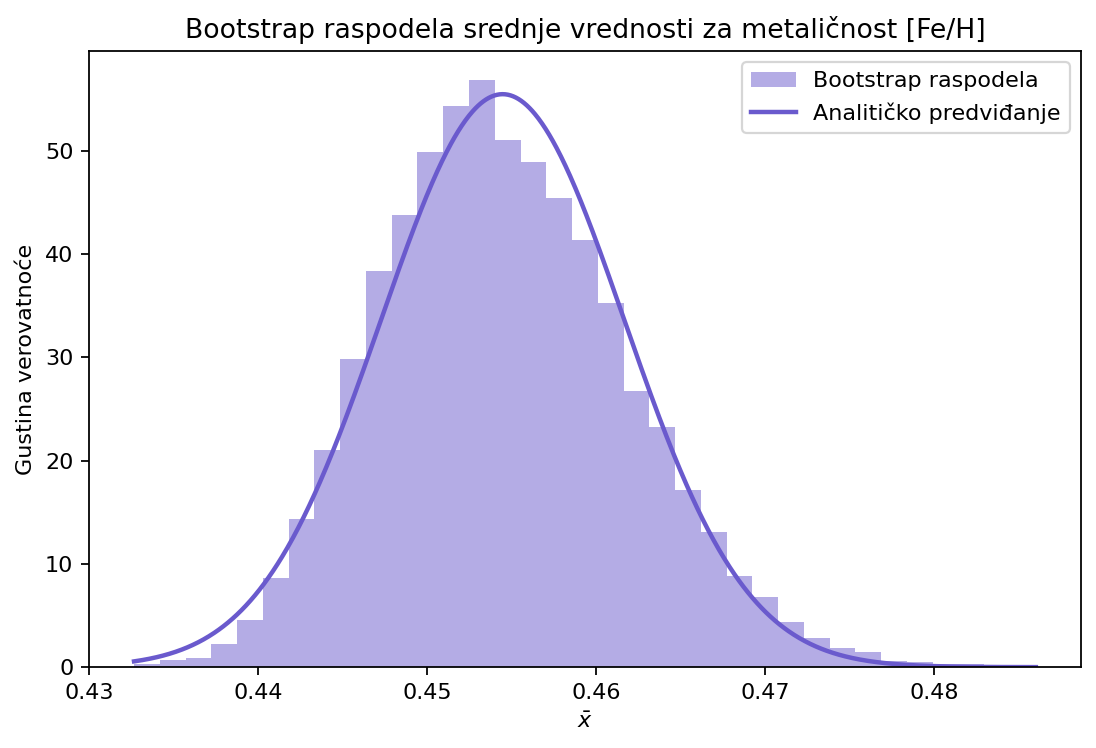

In [47]:
# mreža x-vrednosti za glatku analitičku krivu
x_grid = np.linspace(min(bootstrap_sr), max(bootstrap_sr), 1000)


plt.figure(figsize=(8,5), dpi = 160)

# bootstrap histogram
plt.hist(
    bootstrap_sr,
    bins=35,
    density=True,
    color = 'slateblue',
    alpha=0.5,
    label="Bootstrap raspodela"
)

# analitička normalna raspodela
plt.plot(
    x_grid,
    norm.pdf(x_grid, loc=x_sr, scale=sigma_sr_anal),
    linewidth=2,
    color = 'slateblue',
    label="Analitičko predviđanje"
)

plt.xlabel(r'$\bar{x}$')
plt.ylabel("Gustina verovatnoće")
plt.title("Bootstrap raspodela srednje vrednosti za metaličnost [Fe/H]")
plt.legend()
plt.show()

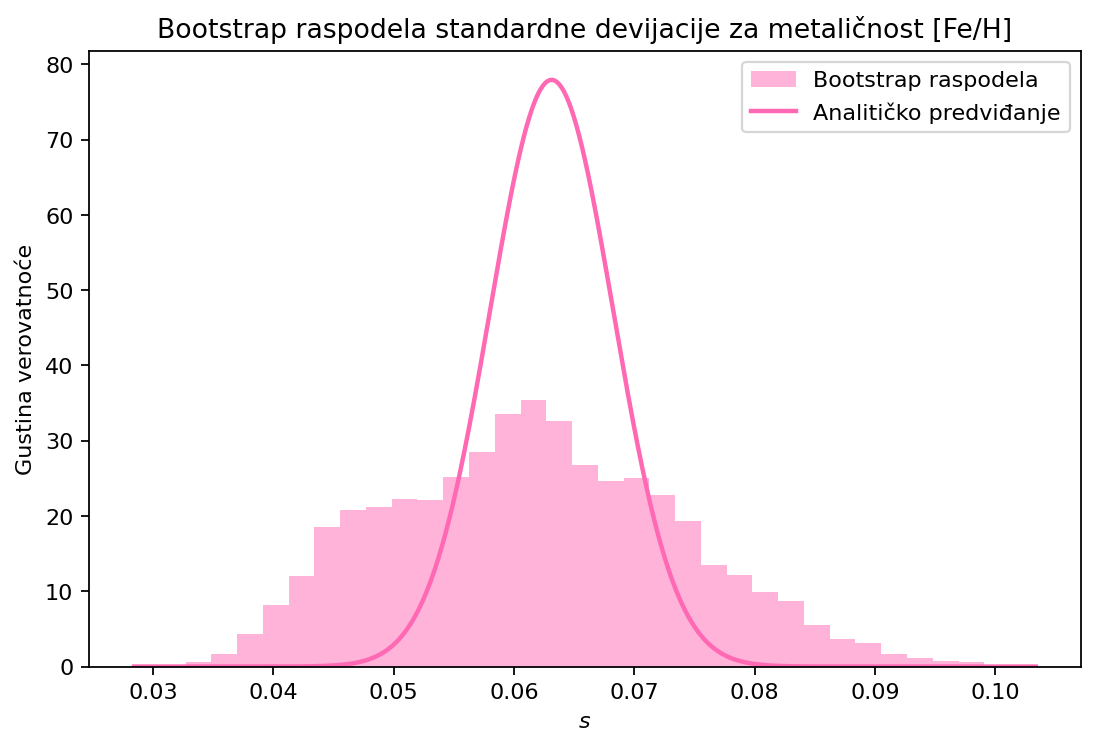

In [121]:
s_grid = np.linspace(min(bootstrap_std), max(bootstrap_std), 1000)

plt.figure(figsize=(8,5), dpi=160)

plt.hist(
    bootstrap_std,
    bins=35,
    density=True,
    alpha=0.5,
    color='hotpink',
    label="Bootstrap raspodela"
)

plt.plot(
    s_grid,
    norm.pdf(s_grid, loc=x_std, scale=sigma_std_anal),
    linewidth=2,
    color='hotpink',
    label="Analitičko predviđanje"
)

plt.xlabel(r'$s$')
plt.ylabel("Gustina verovatnoće")
plt.title("Bootstrap raspodela standardne devijacije za metaličnost [Fe/H]")
plt.legend()
plt.show()

Pretpostavka normalnosti nije jednako opravdana za uzoračku srednju vrednost $\bar{x}$ i uzoračku standardnu devijaciju $s$. Bootstrap raspodela srednje vrednosti $\bar{x}$ je približno simetrična i dobro se poklapa sa analitičkim predviđanjem normalne raspodele čija je širina određena izrazom $\sigma_{\bar{x}}$. Ovo je očekivano, jer se srednja vrednost za dovoljno veliki uzorak ponaša približno normalno, u skladu sa CGT.

Sa druge strane, bootstrap raspodela standardne devijacije $s$ pokazuje veće odstupanje od analitičkog normalnog predviđanja. Raspodela standardne devijacije ne mora biti simetrična, jer je $s$ pozitivno definisana veličina i osetljivija je na oblik početne raspodele i ekstremne vrednosti u uzorku. Zbog toga je pretpostavka normalnosti opravdanija za $\bar{x}$ nego za $s$.

Jackknife metoda je slična bootstrap-u ali umesto da pravi mnogo novih uzoraka sa ponavljanjem ona svaki put izbaci po jedan element iz početnog uzorka. Ne bi nužno dala bolje rezultate od bootstrap metode. Za srednju vrednost bi jackknife verovatno dao sličnu procenu neodređenosti, jer je $\bar{x}$ stabilna statistika. Međutim, za standardnu devijaciju $s$, bootstrap je pogodniji jer procenjuje oblik raspodele statistike ponovnim uzorkovanjem i ne oslanja se toliko na pretpostavku normalnosti. Zato se u ovom slučaju bootstrap metoda može smatrati informativnijom i pouzdanijom, posebno za procenu neodređenosti standardne devijacije.

#### **Četvrti zadatak**

Pre zadatka dat je primer nalaženja AIC u slučaju mešavine tri normalne raspodele. Sličnu proceduru treba primeniti na raspodeli $R_P$. Koristeći GMM i AIC odrediti optimalan broj komponenti M i prikazati fitovane raspodele. Interpretirati rezultat. Zatim proceduru odraditi samo za $\texttt{discoverymethod=='Trasit'}$. Trebalo bi da se u oba slučaja uočavaju neke $\textit{praznine}$. 

In [66]:
#Uzimamo radijuse planeta
Rp1 = exo["pl_rade"].dropna() #u jedinicama Zemljinog poluprečnika

#prebacuje se u logaritamsku skalu jer je raspodela dosta asimetrična, ima više malih planeta od velikih
#a GMM model pretpostavlja da će podaci biti opisani kao zbir normalnih raspodela
#pandas kolonu pretvaramo u niz pa računamo log vrednosti
Rp = np.log10(Rp1.values).reshape(-1, 1)

#Proizvoljan broj raspodela kojim treba opisati celu raspodelu, nakon više iteracija se može zaključiti 
#šta je najbolji izbor
M_vrednosti = np.arange(1, 11)

modeli = []
AIC = []

#Za svaku vrednost M pravi se GMM model, on je matematicki p(x) = summa (alfa_{i}*N(mu_{i}, sigma_{i}))
#gde su parametri alfa_i težine komponenti, mu_i njihove srednje vrednosti i sigma_i širine
#Najbolje vrednosti ovih parametara traži fit i zatim čuva modele
#AIC= 2k - 2lnL se potom računa, k-br parametara i L maksimalna vrednost likelihood funkcije
for M in M_vrednosti:
    model = GM(n_components=M, random_state=1)
    model.fit(Rp)
    modeli.append(model)
    AIC.append(model.aic(Rp))

AIC = np.array(AIC)

#Poenta je da AIC bude što manji jer on označava bolji model, govori da li dodavanjem komponenata model 
#postaje nepotrebno komplikovan ili poboljšava opisivanje raspodele
#Traži se indeks minimalne vrednosti da bi se locirali i broj raspodela i model napravljen pomoću njih 
najbolji = np.argmin(AIC)
najbolje_M = M_vrednosti[najbolji]
najbolji_model = modeli[najbolji]

print("Optimalan broj komponenti M =", najbolje_M)

Optimalan broj komponenti M = 7


<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Tasa\AppData\Local\Temp\ipykernel_29984\3824875446.py:48: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"GMM fit raspodele $\log(R_p/R_\oplus)$, M = {najbolje_M}")


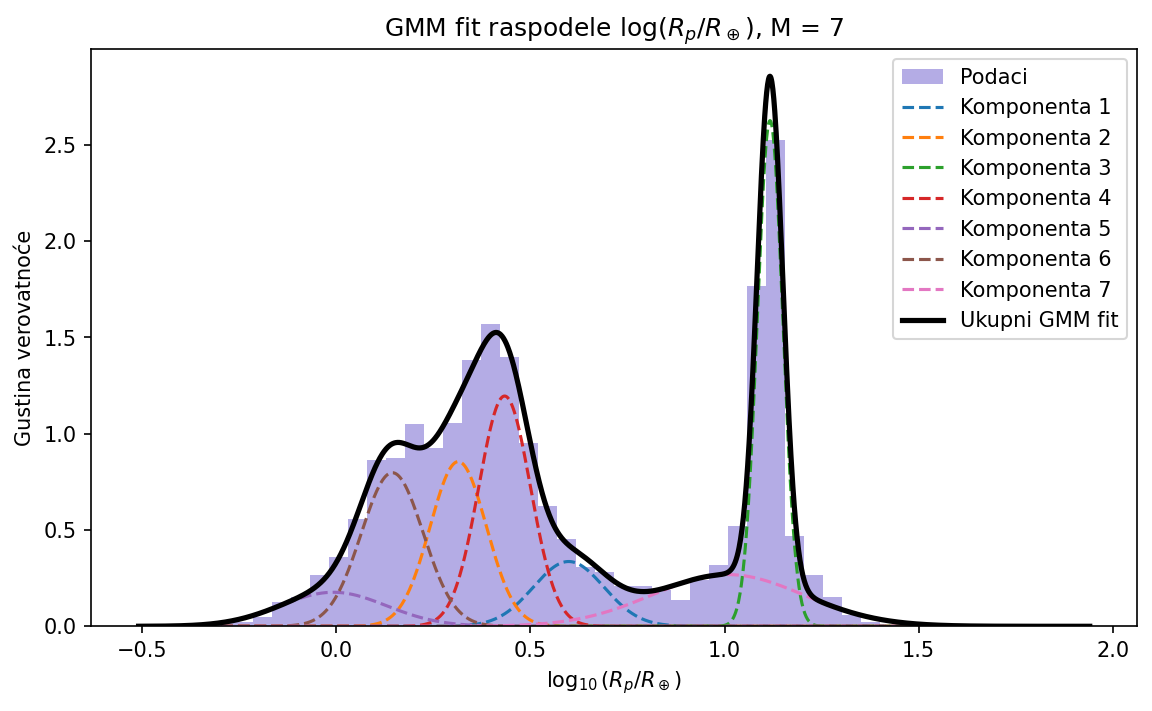

In [93]:
#Niz vrednosti za x osu
rp_vr = np.linspace(Rp.min(), Rp.max(), 2000)

#Traženi parametri modela
tezine = najbolji_model.weights_
sredine = najbolji_model.means_.flatten()
sigme = np.sqrt(najbolji_model.covariances_.flatten()) #GMM čuva varijanse a za normalnu raspodelu tražimo std

#Pravimo prazan niz sa vrednostima koje ćemo popunjavati komponentama fita
ukupni_fit = np.zeros_like(rp_vr)

plt.figure(figsize=(9, 5), dpi=150)

#Histogram podataka koji opisujemo raspodelom
plt.hist(
    Rp,
    bins=50,
    density=True,
    alpha=0.5,
    color='slateblue',
    label="Podaci"
)

#Crtamo svaku komponentu posebno
for j in range(najbolje_M):
    komponenta = tezine[j] * norm.pdf(rp_vr, loc=sredine[j], scale=sigme[j])
    ukupni_fit += komponenta
    
    plt.plot(
        rp_vr,
        komponenta,
        linestyle="--",
        linewidth=1.5,
        label=f"Komponenta {j+1}"
    )

#Ukupan GMM fit
plt.plot(
    rp_vr,
    ukupni_fit,
    linewidth=2.5,
    color= 'black',
    label="Ukupni GMM fit"
)

plt.xlabel(r"$\log_{10}(R_p/R_\oplus)$")
plt.ylabel("Gustina verovatnoće")
plt.title(f"GMM fit raspodele $\log(R_p/R_\oplus)$, M = {najbolje_M}")
plt.legend()
plt.show()

In [78]:
#Isto se sada ponovi ali se dodaje uslov da u uzorak ulaze samo egzoplanete detektovane tranyitnom metodom
exo_transit = exo[exo["discoverymethod"] == "Transit"].copy()

Rp_tr1 = exo_transit["pl_rade"].dropna()

Rp_tr = np.log10(Rp_tr1.values).reshape(-1, 1)

M_vrednosti = np.arange(1, 11)

modeli_tr = []
AIC_tr = []

for M in M_vrednosti:
    model = GM(n_components=M, random_state=1)
    model.fit(Rp_tr)
    modeli_tr.append(model)
    AIC_tr.append(model.aic(Rp_tr))

AIC_tr = np.array(AIC_tr)

najbolji_tr = np.argmin(AIC_tr)
najbolje_M_tr = M_vrednosti[najbolji_tr]
najbolji_model_tr = modeli_tr[najbolji_tr]

print("Optimalan broj komponenti za tranzit uzorak M =", najbolje_M_tr)

Optimalan broj komponenti za tranzit uzorak M = 5


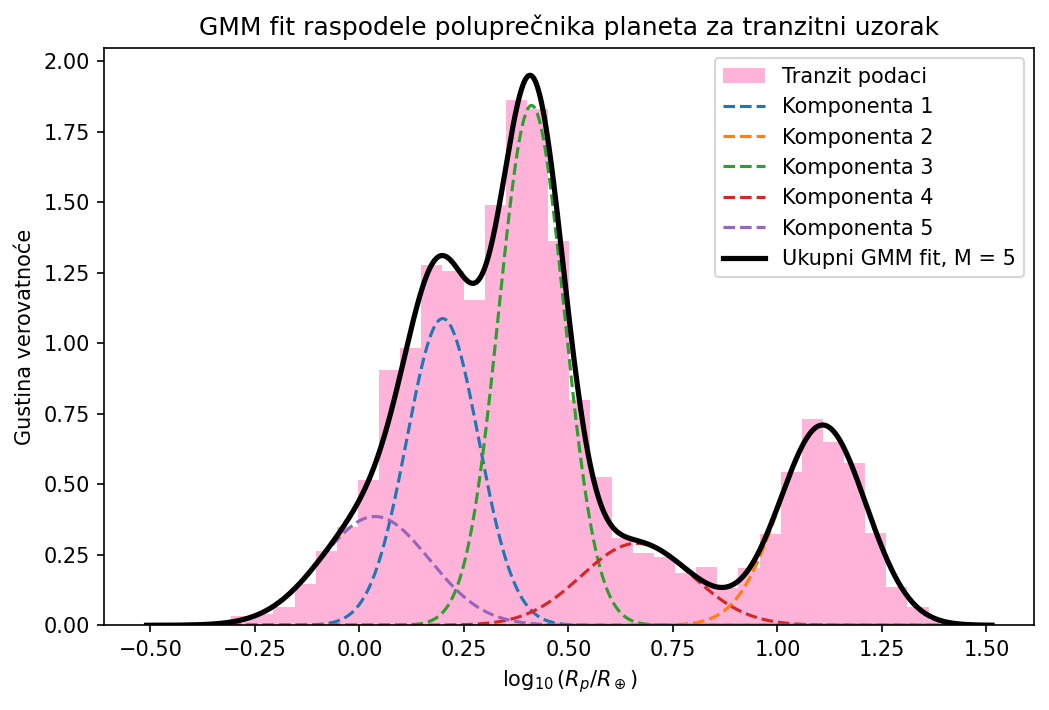

In [104]:
rp_vr_tr = np.linspace(Rp_tr.min(), Rp_tr.max(), 1000).reshape(-1, 1)

logprob_tr = najbolji_model_tr.score_samples(rp_vr_tr)
pdf_tr = np.exp(logprob_tr)


tezine_tr = najbolji_model_tr.weights_
sredine_tr = najbolji_model_tr.means_.flatten()
sigme_tr = np.sqrt(najbolji_model_tr.covariances_.flatten())

plt.figure(figsize=(8, 5), dpi=150)


plt.hist(
    Rp_tr.flatten(),
    bins=40,
    density=True,
    alpha=0.5,
    color='hotpink',
    label="Tranzit podaci"
)


for j in range(najbolje_M_tr):
    komponenta_tr = tezine_tr[j] * norm.pdf(
        rp_vr_tr.flatten(),
        loc=sredine_tr[j],
        scale=sigme_tr[j]
    )
    
    plt.plot(
        rp_vr_tr.flatten(),
        komponenta_tr,
        linestyle="--",
        linewidth=1.5,
        label=f"Komponenta {j+1}"
    )


plt.plot(
    rp_vr_tr.flatten(),
    pdf_tr,
    linewidth=2.5,
    color='black',
    label=f"Ukupni GMM fit, M = {najbolje_M_tr}"
)

plt.xlabel(r"$\log_{10}(R_p/R_\oplus)$")
plt.ylabel("Gustina verovatnoće")
plt.title("GMM fit raspodele poluprečnika planeta za tranzitni uzorak")
plt.legend()
plt.show()

Na dobijenim GMM fitovima vidi se da raspodela poluprečnika planeta nije unimodalna, već da se može opisati pomoću više komponenti. Pojedinačne komponente odgovaraju različitim grupama planeta, od manjih planeta bliskih Zemljinom radijusu, preko sub-Neptunskih planeta, do gasovitih džinova. Između maksimuma ovih komponenti uočavaju se oblasti smanjene gustine, odnosno praznine u raspodeli. 

Posebno je značajna praznina u oblasti malih planeta, približno između $1.5R_\oplus$ i $2.0R_\oplus$. Ova oblast odgovara poznatom radijus gap-u, koji nosi ime Fultonova praznina koja razdvaja populaciju manjih, pretežno stenovitih planeta od populacije većih sub-Neptuna. Fizički, ovo se može tumačiti kao posledica različite evolucije planetarnih atmosfera: planete manjih radijusa su verovatno izgubile gasoviti omotač, dok su veće planete zadržale deo lakih gasova, što ih pomera ka većim radijusima.

U tranzit poduzorku struktura raspodele je jasnije izražena, jer se tranzitnom metodom direktno meri poluprečnik planete i zato je ovaj uzorak pogodniji za analizu raspodele $R_p$. Pored praznine između super-Zemalja i sub-Neptuna, može se uočiti i smanjena zastupljenost planeta između srednjih radijusa i gasovitih džinova, što ukazuje na dodatno razdvajanje planetarnih populacija. Dobijeni rezultat je zato u skladu sa idejom da egzoplanete ne čine jednu kontinuiranu populaciju po radijusu, već više delimično razdvojenih grupa.

#### **Peti zadatak**

Naći planetu čije je $T_{eq}$ najbliže $T_{eq, \oplus}$. Za nju: ispisati broj zvezda u tom sistemu, broj planeta u sistemu, teleskop kojim je planeta otkrivena, masu planete (m_$\oplus$) i ekscentričnost njene orbite. Biće potrebno uraditi novi $\textit{query}$. 

In [98]:
TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

#Unose se novi parametri koji su potrebni za ovaj zadatak, ime planete i njene matične zvezde, broj planeta i zvezda u tom sistemu
# teleskop kojim je otkrivena, njena masa i ekscentricitet
query = """
SELECT
    pl_name,
    hostname,
    pl_eqt,
    sy_snum,
    sy_pnum,
    disc_telescope,
    pl_bmasse,
    pl_orbeccen
FROM pscomppars
WHERE pl_eqt IS NOT NULL
"""
#Zahtev da se pristupi NASA bazi i mesto gde se šalje gore napisan SQL upit
r = requests.get(
    TAP_URL,
    params={"query": query, "format": "csv"},
    timeout=120
)

eq = pd.read_csv(io.StringIO(r.text))
eq.head()

,pl_name,hostname,pl_eqt,sy_snum,sy_pnum,disc_telescope,pl_bmasse,pl_orbeccen
0,Kepler-1167 b,Kepler-1167,1419.0,1,1,0.95 m Kepler Telescope,3.570,0.0
1,Kepler-1740 b,Kepler-1740,858.0,1,1,0.95 m Kepler Telescope,11.000,0.0
2,Kepler-1581 b,Kepler-1581,1108.0,1,1,0.95 m Kepler Telescope,0.437,0.0
3,Kepler-644 b,Kepler-644,1655.0,1,1,0.95 m Kepler Telescope,10.100,0.0
4,Kepler-1752 b,Kepler-1752,419.0,1,1,0.95 m Kepler Telescope,18.700,0.0


In [103]:
#Za ravnotežnu temperaturu na Zemlji se uyima 255K
T_eq_zemlja = 255

#Računa se razlika između temperature kod Zemlje i temperature planeta iz baze
eq["razlika_od_zemlje"] = abs(eq["pl_eqt"] - T_eq_zemlja)

#Tražimo koja je to planeta sa najmanjom vrednosti ove razlike
najbliza = eq.loc[eq["razlika_od_zemlje"].idxmin()]

#Ispis rezultata
print("Planeta čiji je Teq najbliži Zemljinom:")
print("Ime planete:", najbliza["pl_name"])
print("Sistem:", najbliza["hostname"])
print("Teq =", najbliza["pl_eqt"], "K")
print("Razlika u odnosu na Zemlju =", najbliza["razlika_od_zemlje"], "K")

print("\nBroj zvezda u sistemu:", najbliza["sy_snum"])
print("Broj planeta u sistemu:", najbliza["sy_pnum"])
print("Teleskop otkrića:", najbliza["disc_telescope"])
print("Masa planete:", najbliza["pl_bmasse"], "M_Zemlje")
print("Ekscentricitet orbite:", najbliza["pl_orbeccen"])

Planeta čiji je Teq najbliži Zemljinom:
Ime planete: HD 40307 g
Sistem: HD 40307
Teq = 255.0 K
Razlika u odnosu na Zemlju = 0.0 K

Broj zvezda u sistemu: 1
Broj planeta u sistemu: 5
Teleskop otkrića: 3.6 m ESO Telescope
Masa planete: 7.1 M_Zemlje
Ekscentricitet orbite: 0.29


#### **Šesti zadatak**

Koristeći ravnotežnu temperaturu planeta $T_{eq}$, konstruisati empirijsku kumulativnu raspodelu (ECDF). Primeniti metodu inverznog uzorkovanja - generisati $N_{syn} = 10^3$ uzoraka iz uniformne raspodele $U(0, 1)$ i inverznim mapiranjem preko ECDF dobiti sintetičke vrednosti $T_{eq}$. Uporediti raspodelu sintetičkih uzoraka sa originalnom (preko histograma). Da li se ova metoda suštinski razlikuje od npr. $\textit{bootstrap}$ metode? Ako da, kako? Koju raspodelu biste fitovali na $T_{eq}$ i zašto?

Broj planeta sa poznatim Teq: 4693


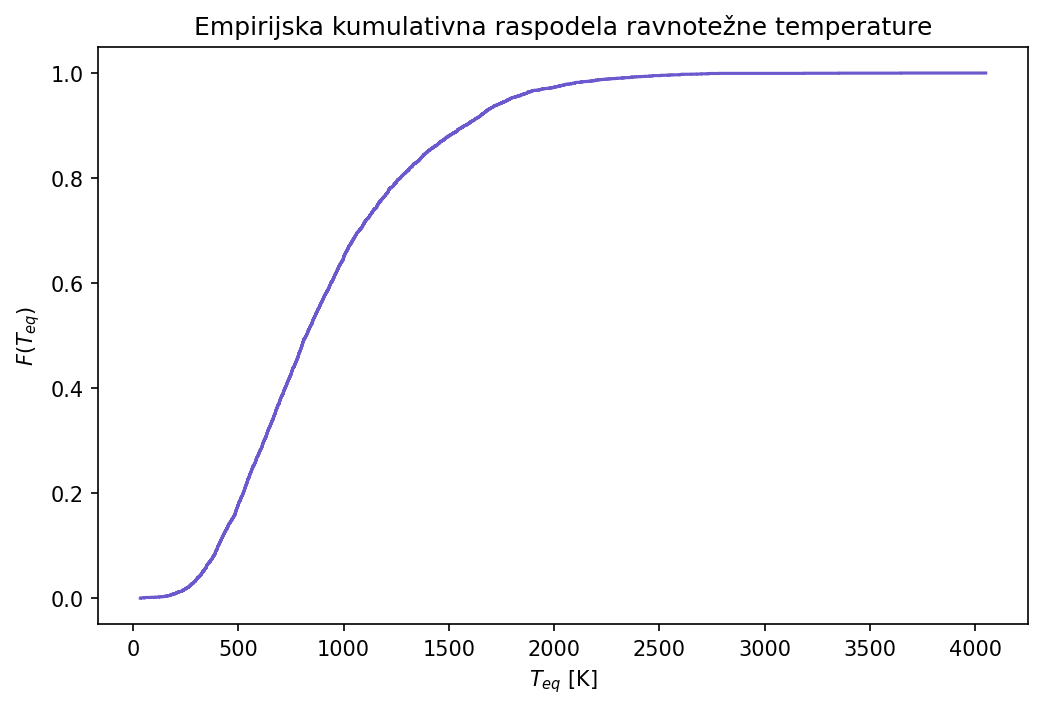

In [120]:
#Uzimamo samo poznate vrednosti ravnotežne temperature
Teq = exo["pl_eqt"].dropna().values

N = len(Teq)

print("Broj planeta sa poznatim Teq:", N)

#Za sortirane podatke empirijska kumulativna raspodela se konstruiše kao F(T_i = i/N)
Teq_sort = np.sort(Teq)

F = np.arange(1, N+1)/N

#Vizuelizacija
plt.figure(figsize=(8, 5), dpi=150)

plt.step(Teq_sort, F, color = 'slateblue')

plt.xlabel(r"$T_{eq}$ [K]")
plt.ylabel(r"$F(T_{eq})$")
plt.title("Empirijska kumulativna raspodela ravnotežne temperature")

plt.show()

In [107]:
#Kod metode inverznog uzorkovanja je ideja da se prvo generišu slučajni brojevi iz uniformne raspodele
#U(0,1) i da se za svako u traži vrednost temperature za koju će važiti da je F(Teq = u)
N_syn = 10**3 #broj uzoraka iz uniformne raspodele

u = np.random.uniform(0, 1, N_syn) #niz od hiljadu brojeva iz uniformne raspodele

Teq_syn = np.interp(u, F, Teq_sort) #sntetičke vrednosti ravnotežne temperature, dobijene preko inverznog mapiranja ECDF

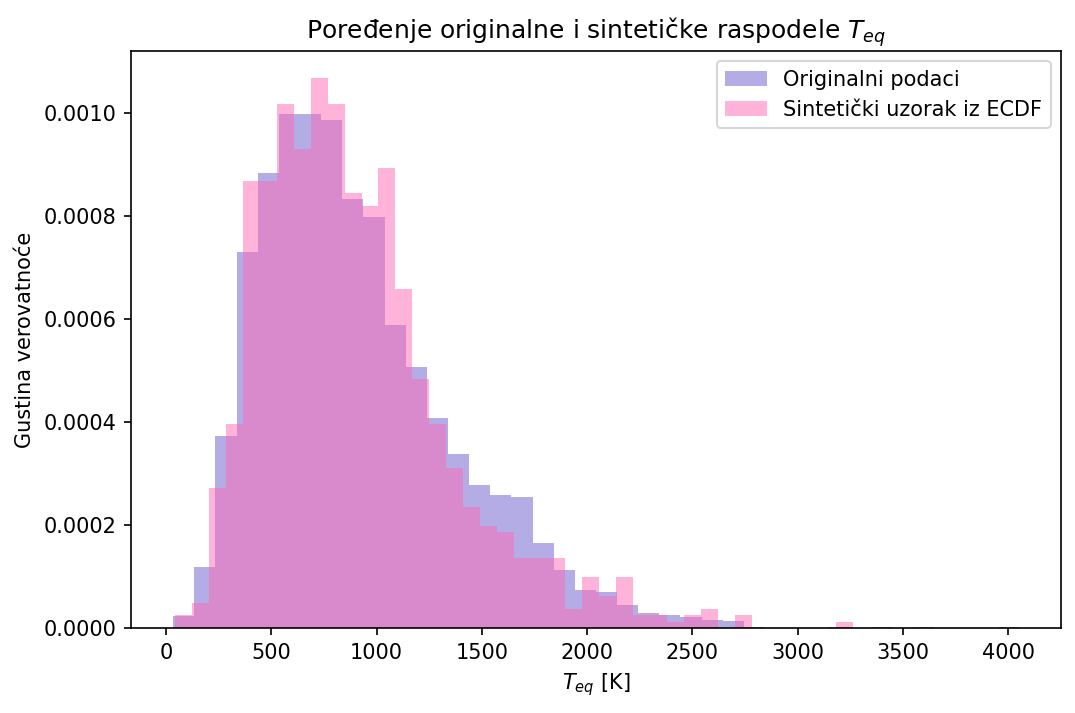

In [119]:
#Vizuelno poređenje raspodele dobijenih sintetičkih vrednosti temperature i originalne raspodele 
plt.figure(figsize=(8, 5), dpi=150)

plt.hist(
    Teq,
    bins=40,
    density=True,
    alpha=0.5,
    color = 'slateblue',
    label="Originalni podaci"
)

plt.hist(
    Teq_syn,
    bins=40,
    density=True,
    alpha=0.5,
    color = 'hotpink',
    label="Sintetički uzorak iz ECDF"
)

plt.xlabel(r"$T_{eq}$ [K]")
plt.ylabel("Gustina verovatnoće")
plt.title("Poređenje originalne i sintetičke raspodele $T_{eq}$")
plt.legend()

plt.show()

Metoda inverznog uzorkovanja preko ECDF i bootstrap su slične po tome što obe koriste empirijsku raspodelu originalnih podataka. Međutim, razlikuju se po tome što bootstrap sve vrednosti bira iz skupa originalnih, dok ova metoda može koristiti i interpolaciju i generisati i vrednosti između originalnih tačaka pa daje glađi sintetički uzorak. Glavna razlika je u cilju metode gde se bootstrap koristi za procenu neodređenosti neke statistike a inverzno uzorkovanje preko ECDF za generisanje sintetičkih podataka koji prate istu raspodelu kao originalni bez pretpostavke kakva ona mora biti. 

Poslednje pitanje jeste kojom raspodelom bi trebalo fitovati $T_{eq}$ i zašto. 

Raspodelu ravnotežnih temperatura ne bih fitovala normalnom raspodelom zbog toga što su sve vrednosti pozivitno definisane i ne mora biti simetrična. Umesto toga _log-normalna_ raspodela opisuje pozitivne veličine sa izraženom asimetrijom što deluje kao pogodan izbor. Definisana je kao pozitivna veličina jer fizički ne može biti manja od nule a asimetrična je sa dugim repom zbog pristrasnosti kataloga ka metodama koje detektuju planete bliže matičnoj zvezdi zbog čega dobijaju veće količine zračenja, pa samim tim imaju i više $T_{eq}$.